# Модуль 6. Градиентный бустинг для классификации

**Интерактивная версия:** `lessons/lesson_6/web/index.html`

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from gbcourse import datasets, GBClassifier
from gbcourse.plotting import use_course_style, plot_decision_surface, plot_learning_curves

use_course_style()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


расхождение вероятностей с sklearn: 2.220446049250313e-16


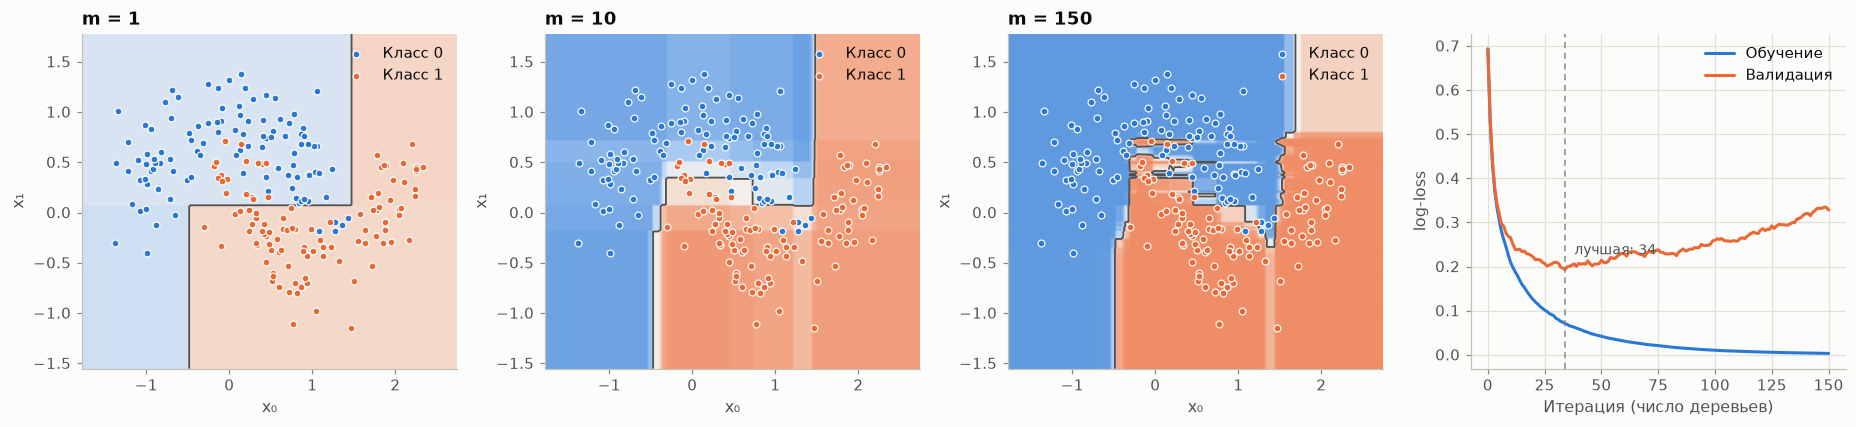

In [2]:
X, y = datasets.classification_2d(kind="moons", n=300, noise=0.25, seed=61)
X_tr, X_val, y_tr, y_val = datasets.train_test_split(X, y, test_size=0.3, seed=0)
model = GBClassifier(n_estimators=150, learning_rate=0.3, max_depth=2).fit(X_tr, y_tr, eval_set=(X_val, y_val))
sk = GradientBoostingClassifier(n_estimators=150, learning_rate=0.3, max_depth=2).fit(X_tr, y_tr)
print("расхождение вероятностей с sklearn:", np.abs(model.predict_proba(X_tr) - sk.predict_proba(X_tr)).max())

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, m in zip(axes[:3], (1, 10, 150)):
    plot_decision_surface(ax, lambda Z, m=m: model.predict_proba(Z, n_iter=m), X_tr, y_tr, title=f"m = {m}")
plot_learning_curves(axes[3], model.history_, best_iteration=model.best_iteration_, ylabel="log-loss")
plt.tight_layout()
plt.show()

Сумма деревьев — логарифм шансов; посмотрим на его распределение и на вероятности:

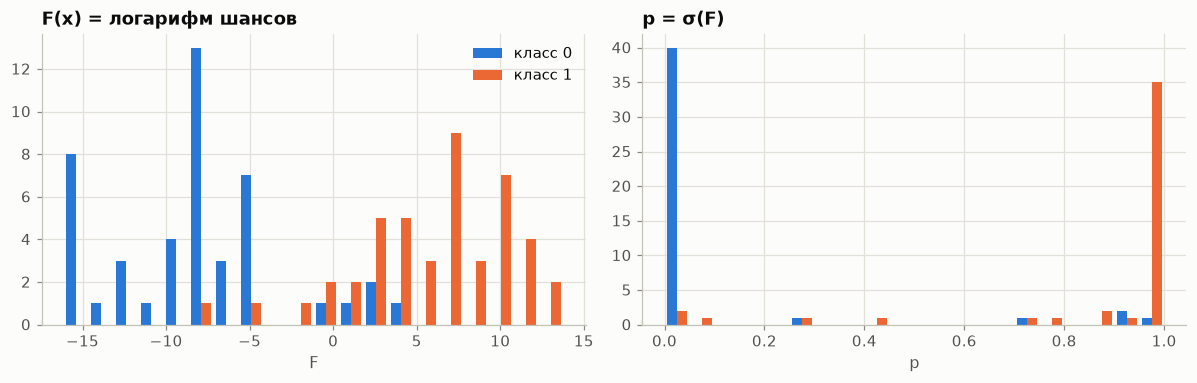

In [3]:
F = model.predict_raw(X_val)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist([F[y_val == 0], F[y_val == 1]], bins=20, label=["класс 0", "класс 1"])
axes[0].set(title="F(x) = логарифм шансов", xlabel="F")
axes[1].hist([1 / (1 + np.exp(-F[y_val == 0])), 1 / (1 + np.exp(-F[y_val == 1]))], bins=20, label=["класс 0", "класс 1"])
axes[1].set(title="p = σ(F)", xlabel="p")
axes[0].legend()
plt.tight_layout()
plt.show()

## Упражнения

1. Сколько деревьев выбирает ранняя остановка по log-loss на валидации? А по точности?

Решения: `python lessons/lesson_6/exercises/solutions.py`.